In [2]:
!git clone https://github.com/AleksandraJuchniewicz/Analiza-danych.git

'git' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
%cd Analiza-danych
!ls

[WinError 2] Nie można odnaleźć określonego pliku: 'Analiza-danych'
c:\Users\ksepk\Documents\GitHub\Analiza-danych


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import seaborn as sns


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

df_d = pd.read_csv("bdl_data_dewastacja_.csv")
df_poz=pd.read_csv("bdl_data_pozar_.csv")
df_gaz=pd.read_csv("bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv("bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv("bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv("bdl_datailosc_2024_.csv")
df_war=pd.read_csv("bdl_datawartosc_2024_.csv")
df_las=pd.read_csv("bdl_powlas_2024_.csv")
df_lasch=pd.read_csv("bdl_powlaschro_2024_.csv")


In [7]:
dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())



df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']


In [8]:
for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {df['Year'].min()}–{df['Year'].max()}")



df1: 2005–2020
df2: 2009–2024
df3: 1998–2024
df4: 1996–2024
df5: 2010–2024
df6: 2009–2024
df7: 2009–2024
df8: 1998–2024
df9: 1998–2024


In [9]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")


df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df9: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [10]:
from functools import reduce
import numpy as np
from sklearn.preprocessing import StandardScaler
df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)
print(df_all.shape)
print(df_all.head())

df_stand = df_all.drop(columns=["Region", "Year"])
data_norm_3 = (df_stand - df_stand.mean(axis=0,skipna=True,numeric_only=True)) / df_stand.std(axis=0,skipna=True,numeric_only=True,ddof=1)
data_norm_z = df_all[["Region", "Year"]].merge(data_norm_3, left_index=True, right_index=True)
def vec_norm(df_all, axis=0):
    return df_all / np.sqrt(np.nansum(df_all**2, axis=axis))

data_norm_1 = df_stand.apply(vec_norm, axis=0)
data_norm_vec = df_all[["Region", "Year"]].merge(data_norm_1, left_index=True, right_index=True)
def pos_norm(x):
    return (x - np.nanmedian(x)) / (
        np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    )
def uni_norm(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))
data_norm_2 = df_stand.apply(pos_norm)
data_norm_pos = df_all[["Region", "Year"]].merge(data_norm_2, left_index=True, right_index=True)
data_norm_4 = df_stand.apply(uni_norm)
data_norm_uni = df_all[["Region", "Year"]].merge(data_norm_4, left_index=True, right_index=True)

print(data_norm_z.head())
print(data_norm_vec.head())
print(data_norm_pos.head())
print(data_norm_uni.head())

(80, 11)
        Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1  MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2  MAŁOPOLSKIE  2018        52.7   236.0  10483040.0  1841.0          52.3   
3  MAŁOPOLSKIE  2019        54.5   190.0   8996236.0  1635.0          53.5   
4  MAŁOPOLSKIE  2020        56.9   176.0   7002044.0  1088.0          53.5   

   Ilosc  Wartosc     P_lasy  P_lasy_ch  
0   22.0    469.0  202140.16   18043.51  
1   16.0    196.7  202078.00   18112.17  
2    9.0    101.0  201366.39   18143.25  
3   27.0    231.9  201241.09   18197.84  
4   18.0    198.6  201200.81   18238.77  
        Region  Year  Dewastacja    Pozary    Za_gaz    Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016    0.431116 -0.784158 -0.230213  0.075630     -0.901115   
1  MAŁOPOLSKIE  2017    0.125901 -0.738746 -0.156790  0.069387     -0.585550   
2  MAŁOPOLSKIE  2018   -0.3101

In [11]:
#braki
print(df_all.isna().sum())
#duplikaty
print(df_all.duplicated(["Region", "Year"]).sum())

Region          0
Year            0
Dewastacja      0
Pozary          0
Za_gaz          0
Za-pyl          0
Zatrudnienie    0
Ilosc           0
Wartosc         0
P_lasy          0
P_lasy_ch       0
dtype: int64
0


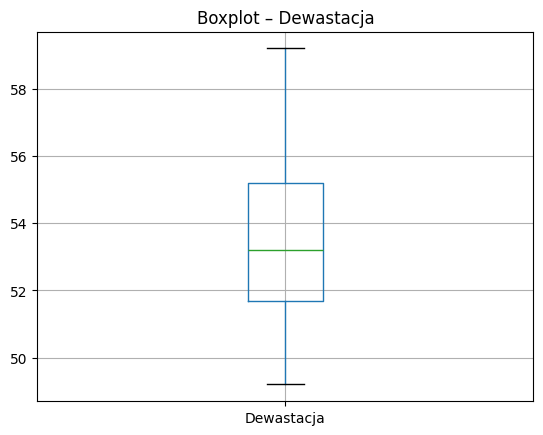

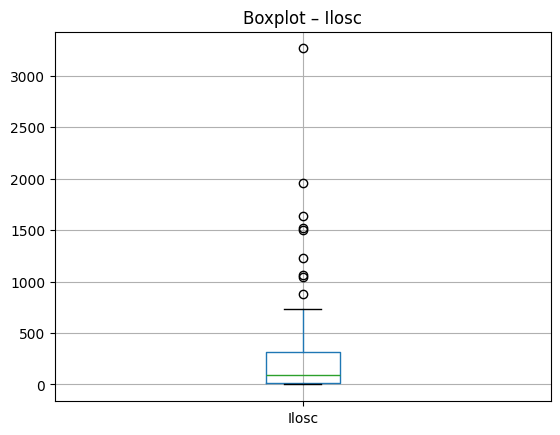

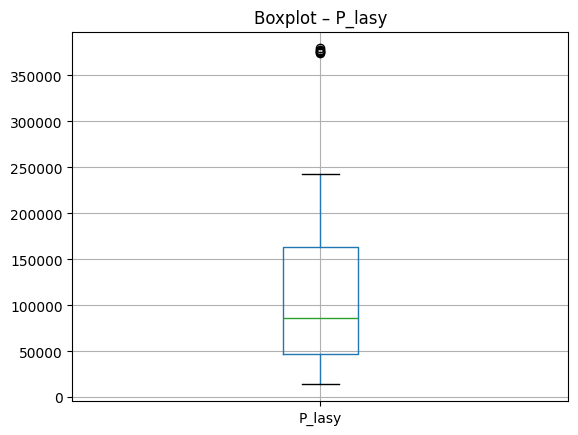

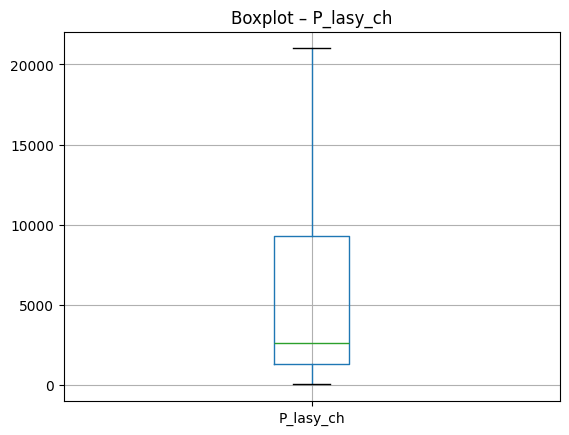

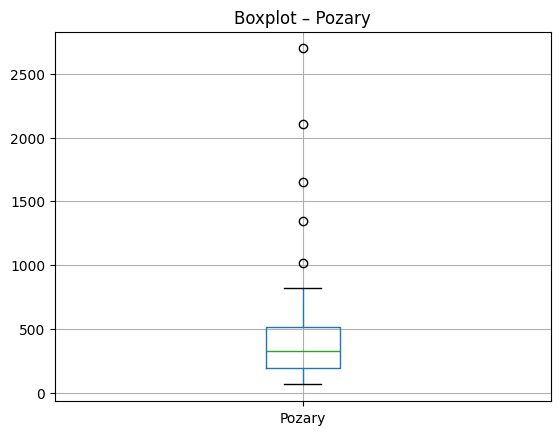

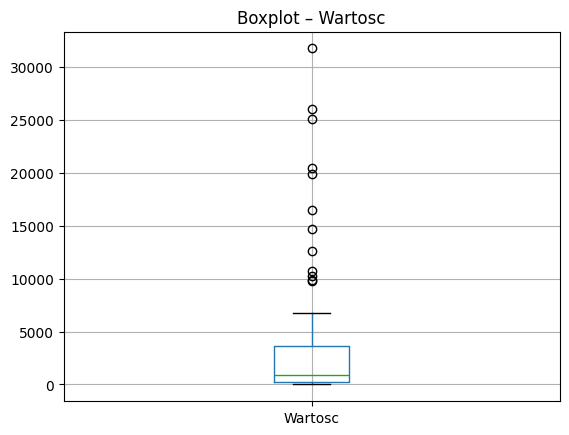

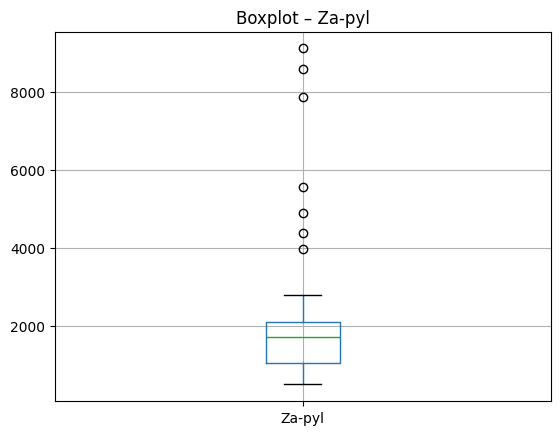

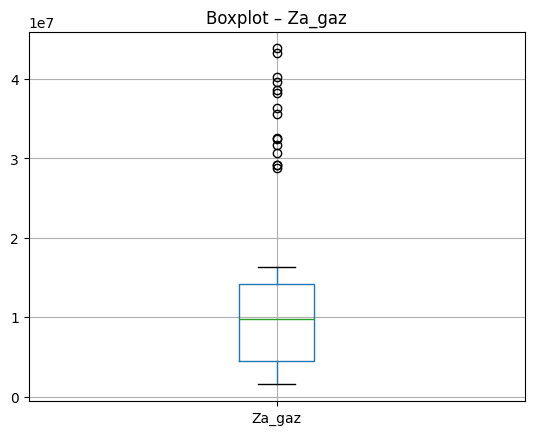

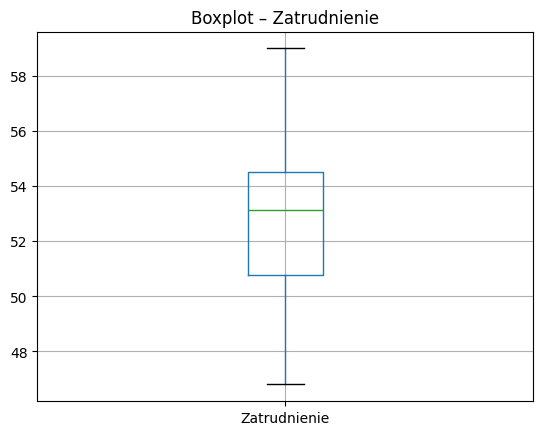

In [12]:
cols_to_plot = df_all.columns.difference(["Region", "Year"])

import matplotlib.pyplot as plt

for col in cols_to_plot:
    plt.figure()
    df_all.boxplot(column=col)
    plt.title(f"Boxplot – {col}")
    plt.show()


In [13]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    outliers["Zmienna"] = col
    outliers["Dolna_granica"] = lower
    outliers["Gorna_granica"] = upper

    return outliers


In [14]:
outlier_list = []

for col in cols_to_plot:
    out = iqr_outliers(df_all, col)
    outlier_list.append(out)

outliers_df = pd.concat(outlier_list, ignore_index=True)

outliers_df = outliers_df[
    ["Zmienna", "Region", "Year", col]
]
outliers_df.groupby("Zmienna").size()
print(outliers_df)



    Zmienna               Region  Year  Zatrudnienie
0     Ilosc             LUBUSKIE  2017          53.7
1     Ilosc             LUBUSKIE  2019          54.5
2     Ilosc        WIELKOPOLSKIE  2016          55.2
3     Ilosc        WIELKOPOLSKIE  2017          57.2
4     Ilosc        WIELKOPOLSKIE  2018          57.7
5     Ilosc        WIELKOPOLSKIE  2019          57.5
6     Ilosc            POMORSKIE  2016          54.6
7     Ilosc            POMORSKIE  2017          56.0
8     Ilosc            POMORSKIE  2019          58.1
9    P_lasy          MAZOWIECKIE  2016          56.2
10   P_lasy          MAZOWIECKIE  2017          57.2
11   P_lasy          MAZOWIECKIE  2018          58.4
12   P_lasy          MAZOWIECKIE  2019          59.0
13   P_lasy          MAZOWIECKIE  2020          58.6
14   Pozary          MAZOWIECKIE  2016          56.2
15   Pozary          MAZOWIECKIE  2017          57.2
16   Pozary          MAZOWIECKIE  2018          58.4
17   Pozary          MAZOWIECKIE  2019        

In [15]:
df_all.drop(columns="Year").describe()

,Dewastacja,Pozary,Za_gaz,Za-pyl,Zatrudnienie,Ilosc,Wartosc,P_lasy,P_lasy_ch
count,80.000000,80.000000,8.000000e+01,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,53.411250,425.087500,1.278226e+07,1945.850000,52.970000,299.050000,3805.297500,116858.864875,5577.767250
std,2.293469,418.394859,1.182737e+07,1601.886168,2.852021,538.047099,6545.550619,96412.072448,5735.863331
min,49.200000,63.000000,1.531405e+06,503.000000,46.800000,0.000000,0.000000,13991.000000,51.150000
25%,51.675000,194.750000,4.533884e+06,1048.000000,50.775000,18.000000,224.750000,47077.070000,1328.385000
50%,53.200000,325.000000,9.755750e+06,1713.000000,53.150000,92.500000,863.250000,86609.380000,2635.355000
75%,55.200000,515.250000,1.413255e+07,2093.250000,54.525000,312.250000,3674.525000,163622.735000,9300.225000
max,59.200000,2699.000000,4.383573e+07,9113.000000,59.000000,3264.000000,31711.900000,379481.590000,21005.560000


In [16]:
num=df_all.drop(columns=["Year"])
df_all_std=(num.mean(axis=0,skipna=True,numeric_only=True))/(num.std(axis=0,skipna=True,numeric_only=True))

In [17]:
print(df_all_std)

Dewastacja      23.288415
Pozary           1.015996
Za_gaz           1.080735
Za-pyl           1.214724
Zatrudnienie    18.572793
Ilosc            0.555806
Wartosc          0.581356
P_lasy           1.212077
P_lasy_ch        0.972437
dtype: float64


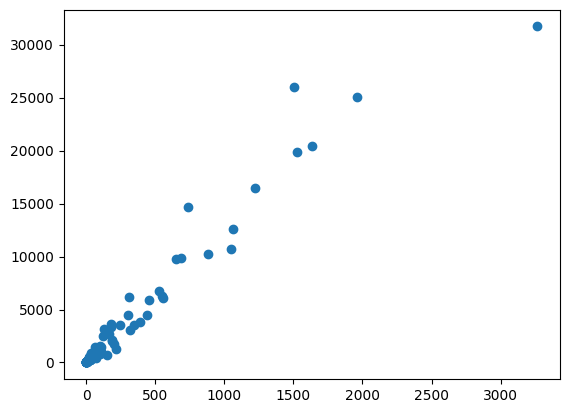

In [18]:
from matplotlib import pyplot as plt
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Wartosc'])
#plt.yscale('log') 
plt.show()

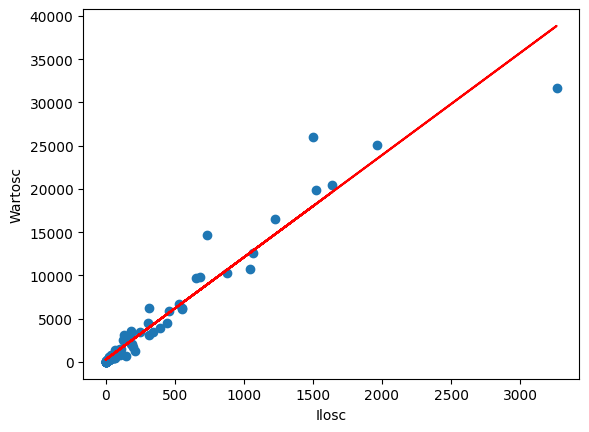

In [19]:
import numpy as np
np.corrcoef(df_all['Ilosc'], df_all['Wartosc'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Wartosc'])
x = df_all['Ilosc']
y = df_all['Wartosc']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit, color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Wartosc')
plt.show()

<Figure size 640x480 with 0 Axes>

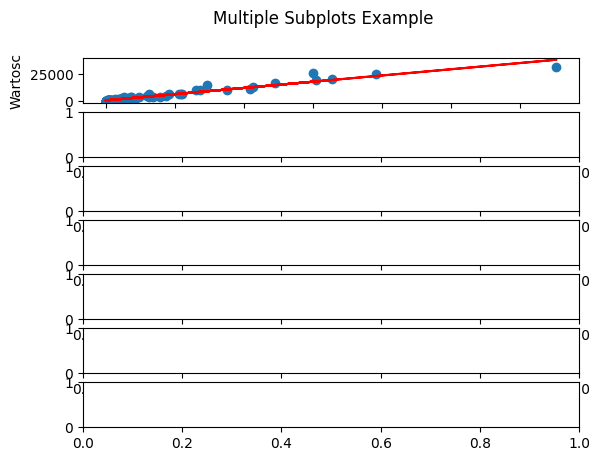

In [20]:
import numpy as np
np.corrcoef(df_all['Ilosc'], df_all['Wartosc'])
plt.clf()
fig, axs = plt.subplots(7)
fig.suptitle('Multiple Subplots Example')
axs[0].scatter(df_all['Ilosc'], df_all['Wartosc'])
x = df_all['Ilosc']
y = df_all['Wartosc']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

axs[0].plot(x, y_fit, color='red', label='Regression line')
axs[0].set_xlabel('Ilosc')
axs[0].set_ylabel('Wartosc')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


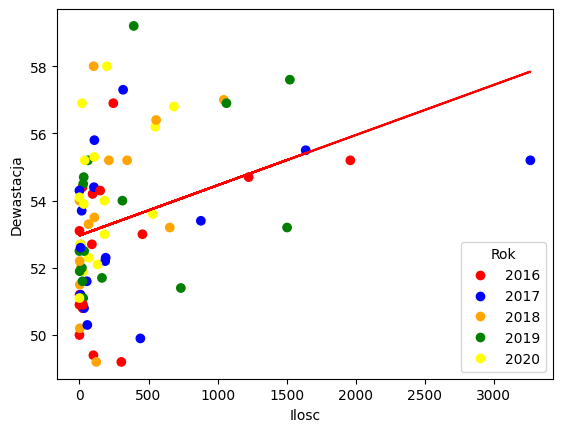

In [78]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Dewastacja'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Dewastacja'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


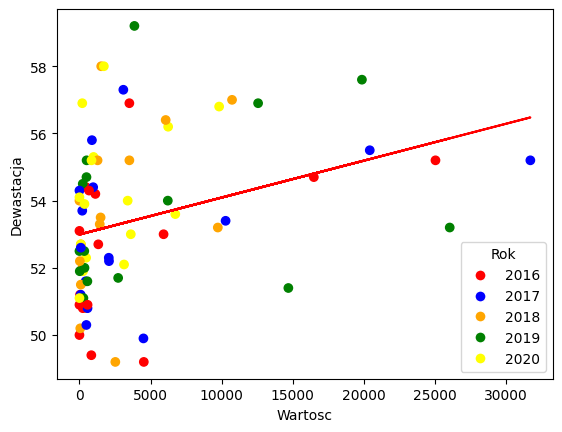

In [79]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Dewastacja'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Dewastacja'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


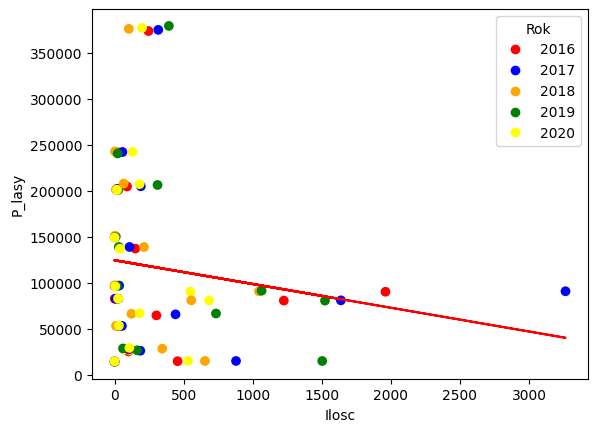

In [83]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['P_lasy'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['P_lasy'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['P_lasy']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('P_lasy')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


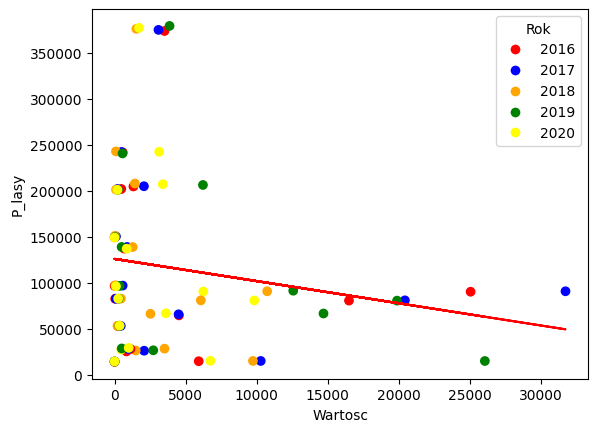

In [81]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['P_lasy'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['P_lasy'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['P_lasy']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('P_lasy')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


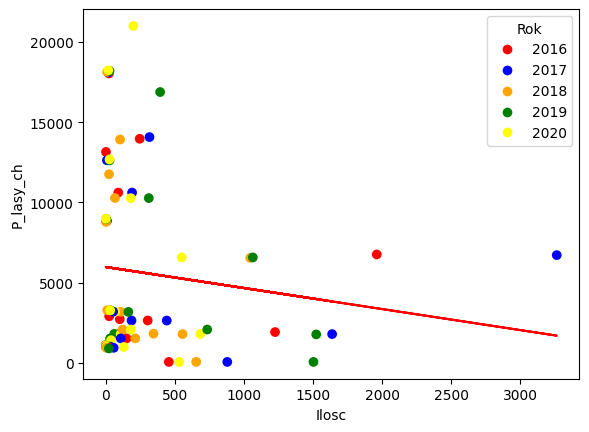

In [82]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['P_lasy_ch'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['P_lasy_ch'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['P_lasy_ch']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('P_lasy_ch')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


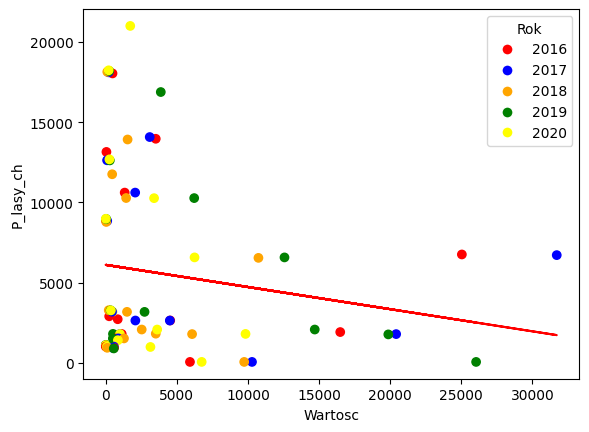

In [87]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['P_lasy_ch'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['P_lasy_ch'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['P_lasy_ch']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('P_lasy_ch')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


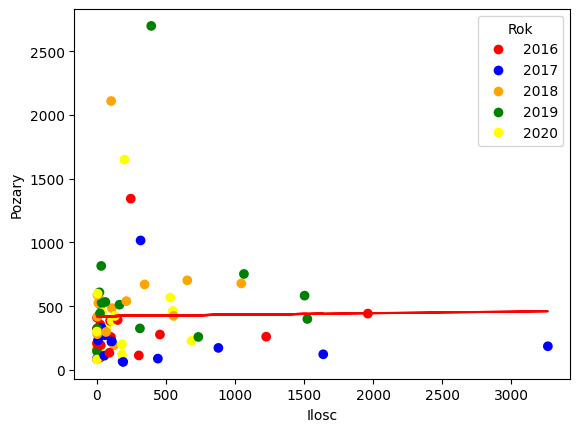

In [88]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Pozary'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Pozary'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Pozary']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


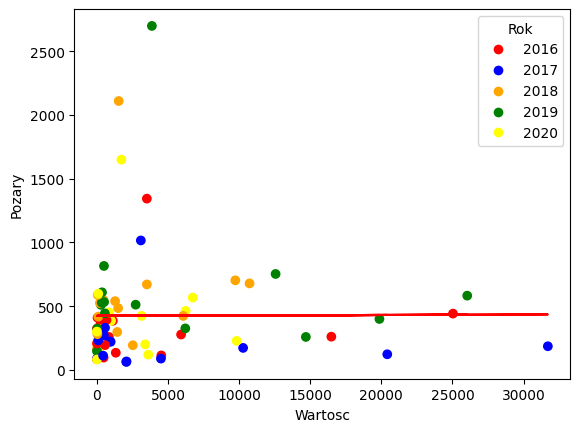

In [89]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Pozary'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Pozary'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Pozary']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


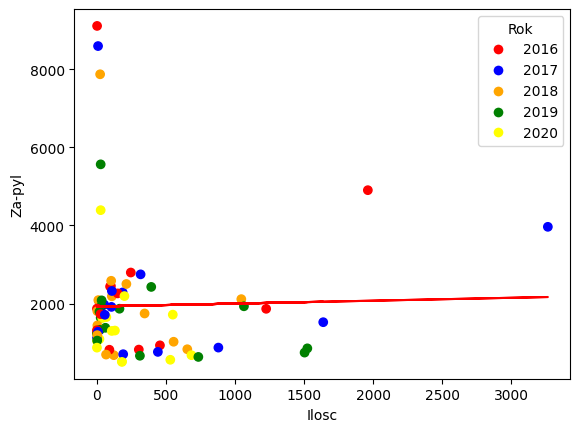

In [90]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Za-pyl'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Za-pyl'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


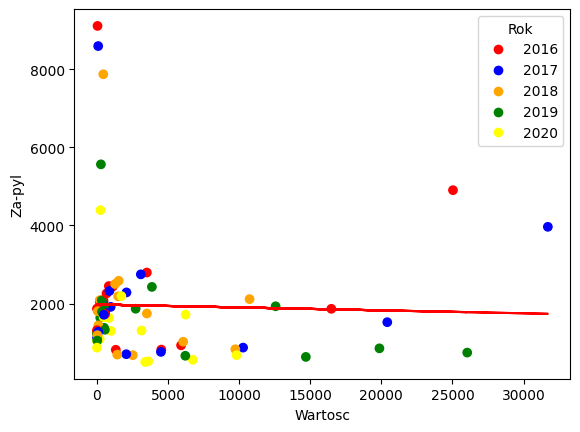

In [91]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Za-pyl'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Za-pyl'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


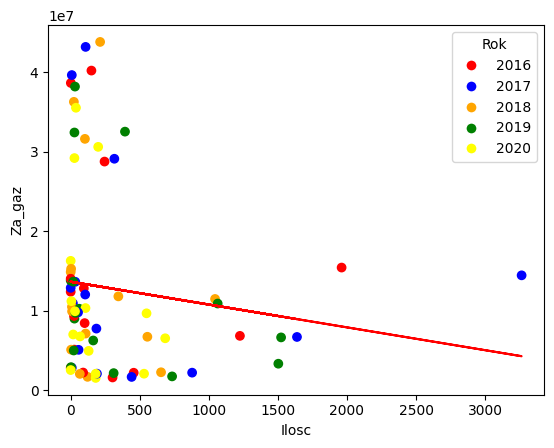

In [92]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Za_gaz'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Za_gaz'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


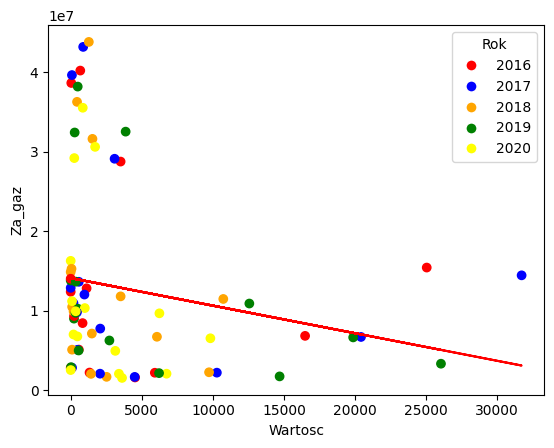

In [93]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Za_gaz'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Za_gaz'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


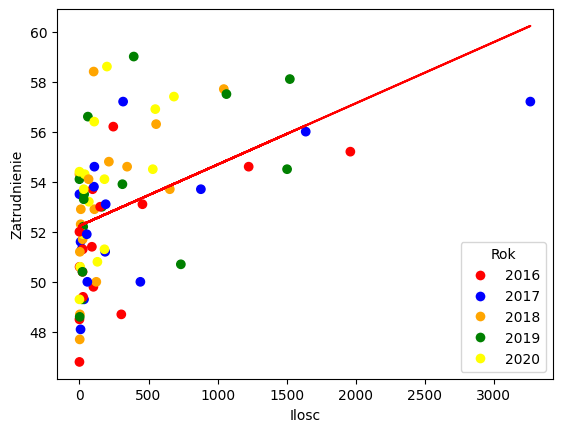

In [94]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Zatrudnienie'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Zatrudnienie'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Zatrudnienie')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


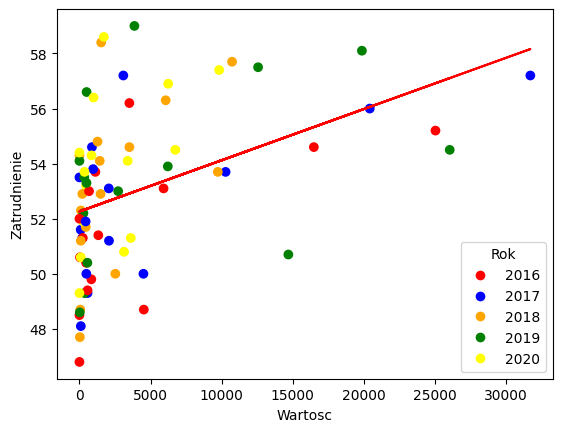

In [95]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Zatrudnienie'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Zatrudnienie'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)       # linear regression: degree 1
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Zatrudnienie')
plt.show()

      Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
30  OPOLSKIE  2016        53.1    85.0  12380388.0  1257.0          52.0   
31  OPOLSKIE  2017        54.3    88.0  12870856.0  1109.0          53.5   
32  OPOLSKIE  2018        54.0   165.0  14871554.0  1257.0          54.3   
33  OPOLSKIE  2019        52.5   148.0  13800974.0  1230.0          54.1   
34  OPOLSKIE  2020        54.1    82.0  16272213.0  1042.0          54.4   

    Ilosc  Wartosc    P_lasy  P_lasy_ch  
30    0.0      0.0  13991.00    1089.19  
31    0.0      0.0  14428.31    1099.50  
32    0.0      0.0  14467.73    1098.94  
33    0.0      0.0  14475.44    1098.60  
34    0.0      0.0  14484.38    1097.25  
         Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0   MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1   MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2   MAŁOPOLSKIE  2018        52.7   236.0  10483040.0 

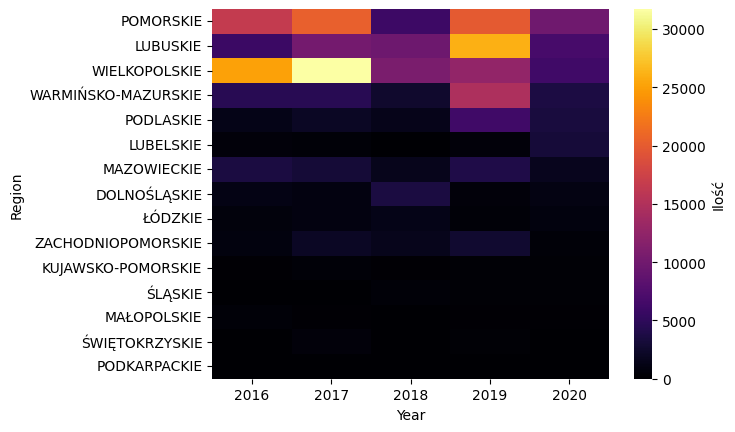

In [122]:
print(df_all[df_all["Region"].isin(["OPOLSKIE"])])
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
print(cleared_data)
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Wartosc").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

      Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
30  OPOLSKIE  2016        53.1    85.0  12380388.0  1257.0          52.0   
31  OPOLSKIE  2017        54.3    88.0  12870856.0  1109.0          53.5   
32  OPOLSKIE  2018        54.0   165.0  14871554.0  1257.0          54.3   
33  OPOLSKIE  2019        52.5   148.0  13800974.0  1230.0          54.1   
34  OPOLSKIE  2020        54.1    82.0  16272213.0  1042.0          54.4   

    Ilosc  Wartosc    P_lasy  P_lasy_ch  
30    0.0      0.0  13991.00    1089.19  
31    0.0      0.0  14428.31    1099.50  
32    0.0      0.0  14467.73    1098.94  
33    0.0      0.0  14475.44    1098.60  
34    0.0      0.0  14484.38    1097.25  
         Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0   MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1   MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2   MAŁOPOLSKIE  2018        52.7   236.0  10483040.0 

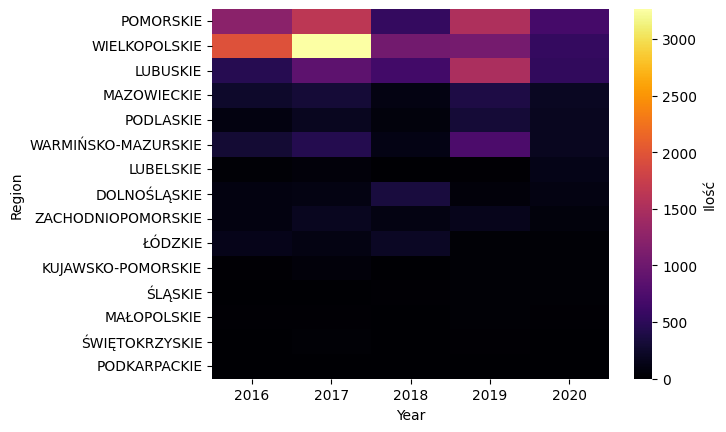

In [ ]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Ilosc").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

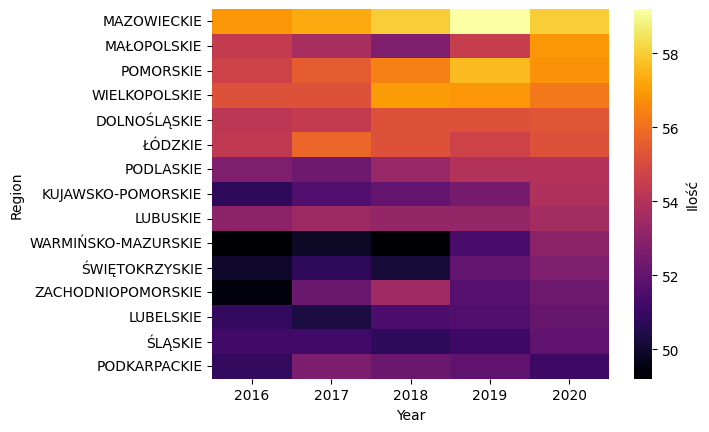

In [124]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Dewastacja").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

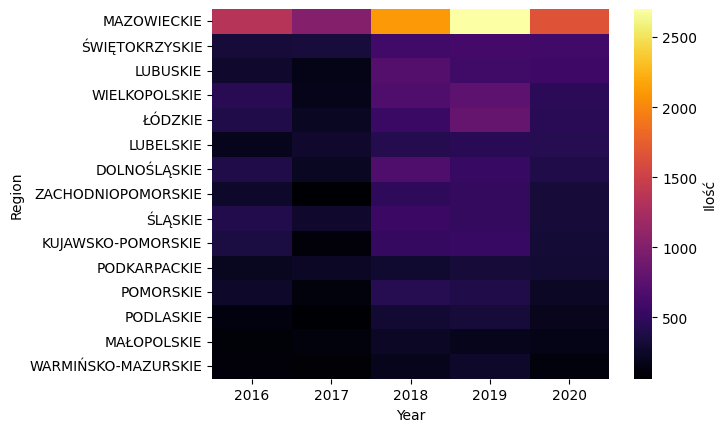

In [125]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Pozary").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

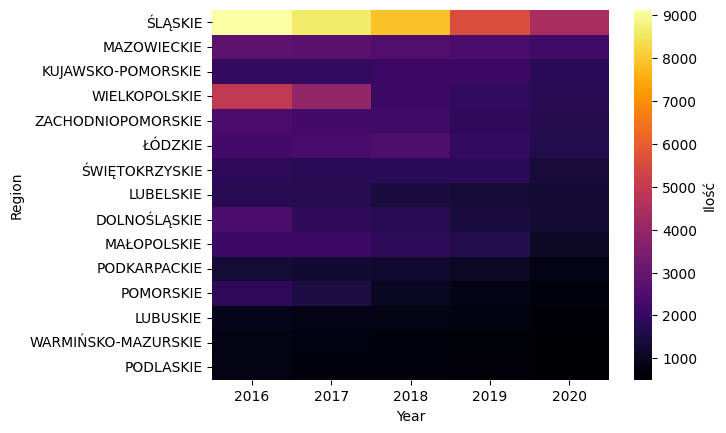

In [127]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Za-pyl").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

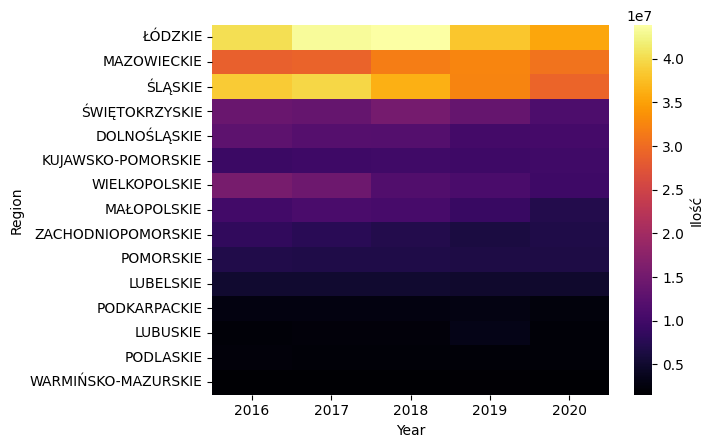

In [128]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Za_gaz").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)

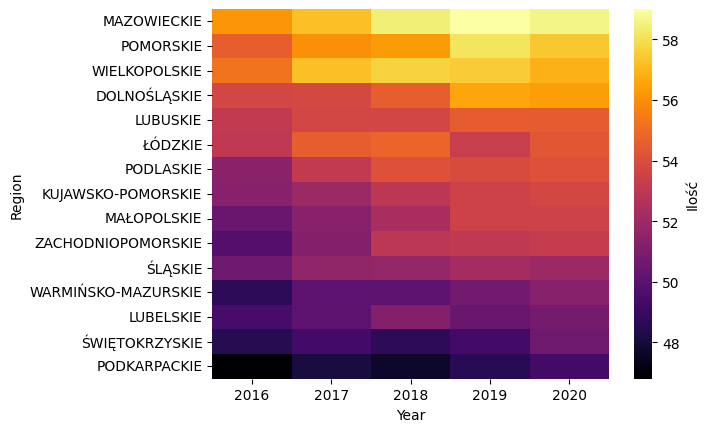

In [129]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Zatrudnienie").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość', rotation=90)